In [1]:
%load_ext autoreload
%autoreload 2

import glob, h5py, math, time, os, json
from scipy.stats import norm, expon, chi2, uniform, chisquare, gamma
import numpy as np

import matplotlib as mpl
import matplotlib.pyplot as plt
import matplotlib.font_manager as font_manager

import sys  
sys.path.insert(1, '../utils/')
import new_nplm as nplm

sys.path.append("../../")
from utils.nplm_postproc import extract_tstat, get_statistics, get_statistics_npy
import utils.plotting as plotting

/n/holystore01/LABS/iaifi_lab/Users/sambt/mamba/envs/torch_gpu/lib/python3.10/site-packages/pandas/core/computation/expressions.py:21: UserWarning: Pandas requires version '2.8.4' or newer of 'numexpr' (version '2.7.3' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED


# CIFAR-10 w/o class 1, class 1 = anomaly; testing with CIFAR-5m

In [2]:
dims = [4,8,12,16,32]
NTOYS = 500
analysis_results = {}
for dim in dims:
    M=100 if dim==4 else 103# number of kernels
    flk_sigmas = [0.1, 1.5, 2.6, 3.6, 4.9, 9.8] # values of kernel's width used for multiple testing

    # files containing the toys for different physics assumptions
    # keep 'ref' as key for the calibraiton toys for consistence
    top_dir = "cifar10_anom1_v2" if dim==4 else f"cifar10_anom1_v2_dim{dim}"
    base_dir = f"../experiments_output/{top_dir}/M{M}_lam1e-07_iter10000000_sigma0.1-1.5-2.6-3.6-4.9-9.8-_NoPois/"
    files_dict = {
        #'ref': f"{base_dir}/Nref8000_Nbkg1000_refOnly/tests_all.h5",
        'ref': f"{base_dir}/Nref9000_Nbkg1800/tests_all.h5",
        0.01: f"{base_dir}/Nref9000_Nbkg1800_Nsig18/tests_all.h5",
        0.02: f"{base_dir}/Nref9000_Nbkg1800_Nsig36/tests_all.h5",
        0.05: f"{base_dir}/Nref9000_Nbkg1800_Nsig90/tests_all.h5",
        0.1: f"{base_dir}/Nref9000_Nbkg1800_Nsig180/tests_all.h5",
        0.2: f"{base_dir}/Nref9000_Nbkg1800_Nsig360/tests_all.h5",
    }
    # key values extraction
    files = list(files_dict.values())
    labels_list = list(files_dict.keys())
    inj_fractions = sorted([k for k in files_dict.keys() if k != 'ref'])

    tstats = extract_tstat(files_dict,flk_sigmas,NTOYS=NTOYS)
    statistics = get_statistics(tstats,flk_sigmas)

    dim_label = f"_dim{dim}" if dim != 4 else ""
    ideal_zscores = np.load(f"/n/home11/sambt/phlab-neurips25/experiments/cifar10/cifar10SpaceWithoutClass1_T0.1_idealZscores_LRtestWithFit_nbkg1.8k_anomClass1_trainedCIFAR10{dim_label}.npz")
    double_ideal_zscores = np.load(f"/n/home11/sambt/phlab-neurips25/experiments/cifar10/cifar10AllClassSpace_T0.1_idealZscores_LRtestWithFit_nbkg1.8k_anomClass1_trainedCIFAR10{dim_label}.npz")
    maha_emp_zscores = np.load(f"/n/home11/sambt/phlab-neurips25/nplm/notebooks_maha/cifar10_maha_empiricalZscore{dim_label}.npz")

    # FID scores
    fid_path = f"/n/home11/sambt/phlab-neurips25/nplm/experiments_output/cifar10_anom1_v2{dim_label}/FID_NoPois/"
    files_dict_fid = {
        'ref': fid_path + "Nref9000_Nbkg1800_Nsig0/test_all.npy",
        0.01: fid_path + "Nref9000_Nbkg1800_Nsig18/test_all.npy",
        0.02: fid_path + "Nref9000_Nbkg1800_Nsig36/test_all.npy",
        0.05: fid_path + "Nref9000_Nbkg1800_Nsig90/test_all.npy",
        0.1: fid_path + "Nref9000_Nbkg1800_Nsig180/test_all.npy",
        0.2: fid_path + "Nref9000_Nbkg1800_Nsig360/test_all.npy"
    }
    tstats_fid = extract_tstat(files_dict_fid, flk_sigmas, NTOYS=NTOYS, ftype='npy')
    statistics_fid = get_statistics_npy(tstats_fid)
    inj_fractions_fid = sorted([k for k in files_dict_fid.keys() if k != 'ref'])

    # MMD scores
    mmd_path = f"/n/home11/sambt/phlab-neurips25/nplm/experiments_output/cifar10_anom1_v2{dim_label}/NysMMD_M103_NoPois/"
    files_dict_mmd = {
        'ref': mmd_path + "Nref9000_Nbkg1800_Nsig0/test_all.npy",
        0.01: mmd_path + "Nref9000_Nbkg1800_Nsig18/test_all.npy",
        0.02: mmd_path + "Nref9000_Nbkg1800_Nsig36/test_all.npy",
        0.05: mmd_path + "Nref9000_Nbkg1800_Nsig90/test_all.npy",
        0.1: mmd_path + "Nref9000_Nbkg1800_Nsig180/test_all.npy",
        0.2: mmd_path + "Nref9000_Nbkg1800_Nsig360/test_all.npy"
    }
    tstats_mmd = extract_tstat(files_dict_mmd, flk_sigmas, NTOYS=NTOYS, ftype='npy')
    statistics_mmd = get_statistics_npy(tstats_mmd)
    inj_fractions_mmd = sorted([k for k in files_dict_mmd.keys() if k != 'ref'])

    analysis_results[dim] = {
        "tstats": tstats,
        "statistics": statistics,
        "ideal_zscores": ideal_zscores,
        "double_ideal_zscores": double_ideal_zscores,
        "maha_emp_zscores": maha_emp_zscores,
        "inj_fractions": inj_fractions,
        "inj_fractions_fid": inj_fractions_fid,
        "z_emp_fid": statistics_fid['z_emp'],
        "inj_fractions_mmd": inj_fractions_mmd,
        "z_emp_mmd": statistics_mmd['z_emp']
    }

## asymptotic nplm z scores

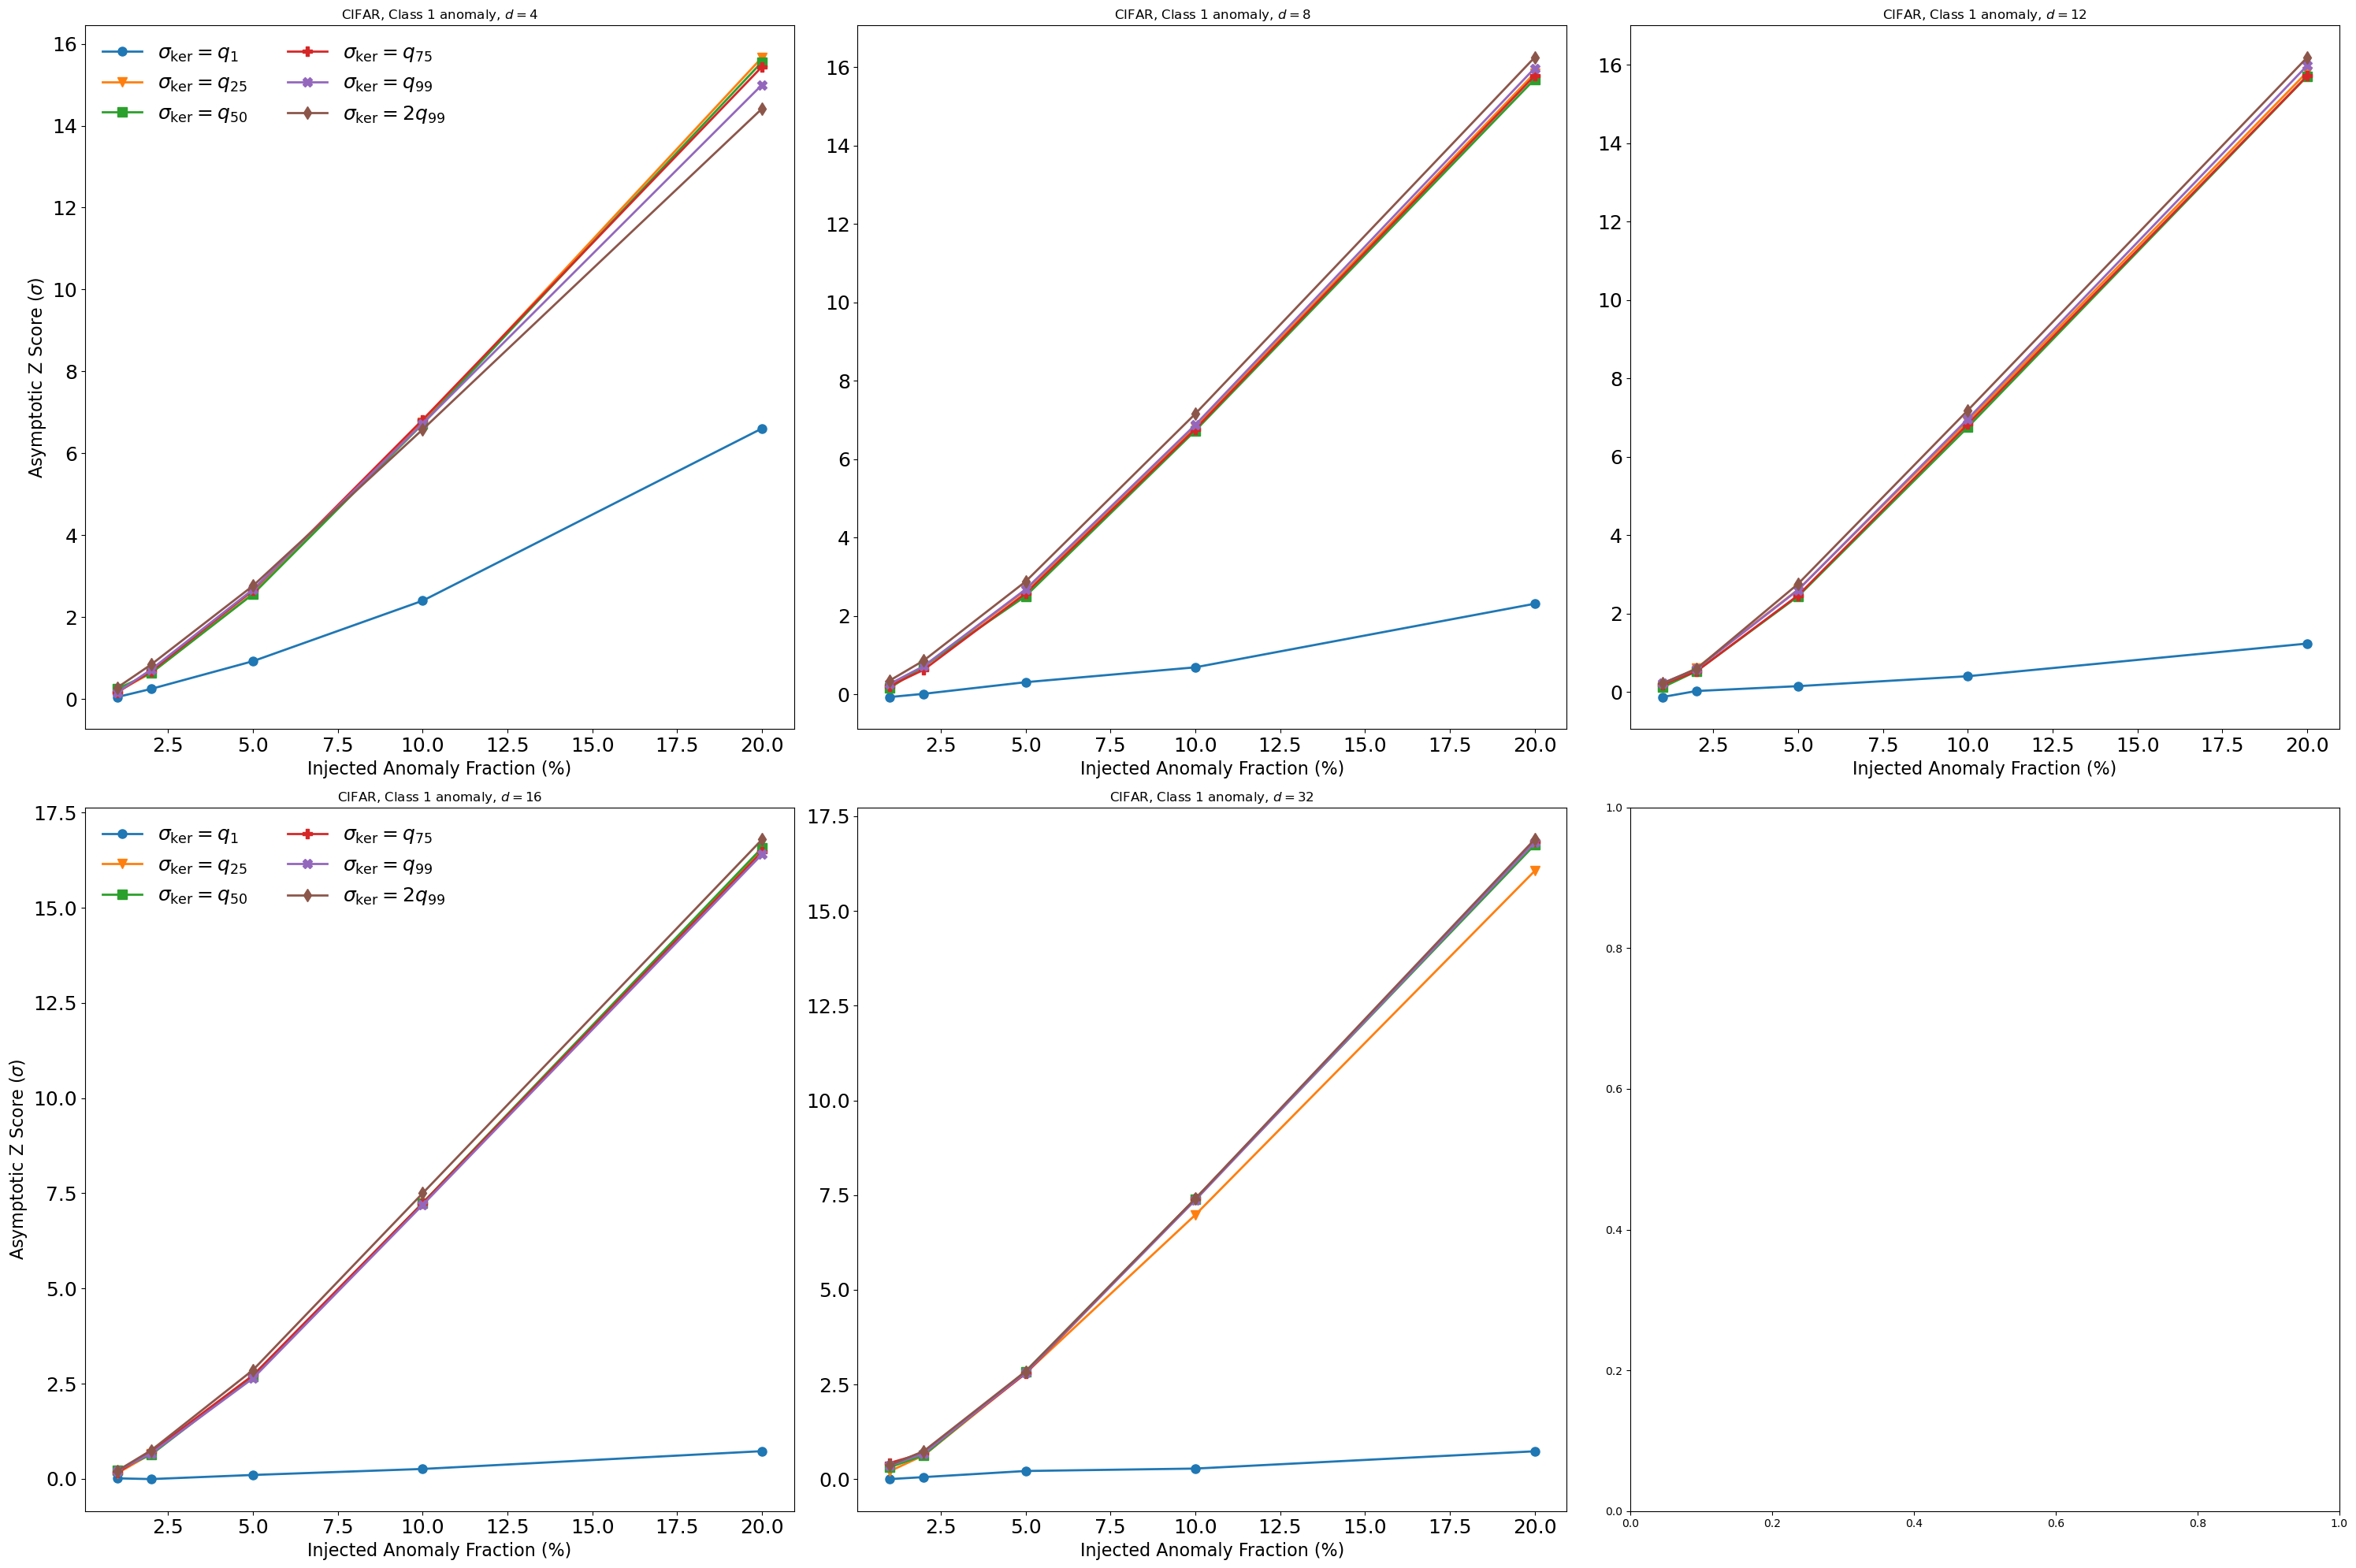

In [4]:
fig, axes = plt.subplots(2,3,figsize=(30,20))
axes = axes.flatten()
for i,dim in enumerate(dims):
    plt.sca(axes[i])
    plt.title(f"CIFAR, Class 1 anomaly, $d = {dim}$",fontsize=12)
    inj_fractions = analysis_results[dim]['inj_fractions']
    z_obs = analysis_results[dim]['statistics']['z_obs']

    x_values = [100*f for f in inj_fractions]
    markers = ['o','v','s','P','X','d']
    for isigma,sigma in enumerate(flk_sigmas):
        y_values = [z_obs[f][:,isigma] for f in inj_fractions]
        plt.plot(x_values,y_values,lw=2,
                marker=markers[isigma],markersize=8,
                color=f"C{isigma}",
                #label=f"$\sigma_\\text{{ker}} = {sigma:.1f}$")
                label=plotting.kernel_to_label[sigma])
    #plt.xscale('log')
    xlim = plt.gca().get_xlim()
    plt.yticks(fontsize=18)
    plt.xticks(fontsize=18)
    if i==0 or i==3:
        plt.ylabel("Asymptotic Z Score ($\sigma$)",fontsize=16)
        plt.legend(ncol=2,fontsize=18,frameon=False)
    plt.xlabel("Injected Anomaly Fraction (%)",fontsize=16)
    #plt.ylim([0,9])
    plt.tight_layout()
plt.savefig(f"cifar_plots/cifar10asymptoticZscores_allSigmas_dimScan.pdf",bbox_inches='tight')

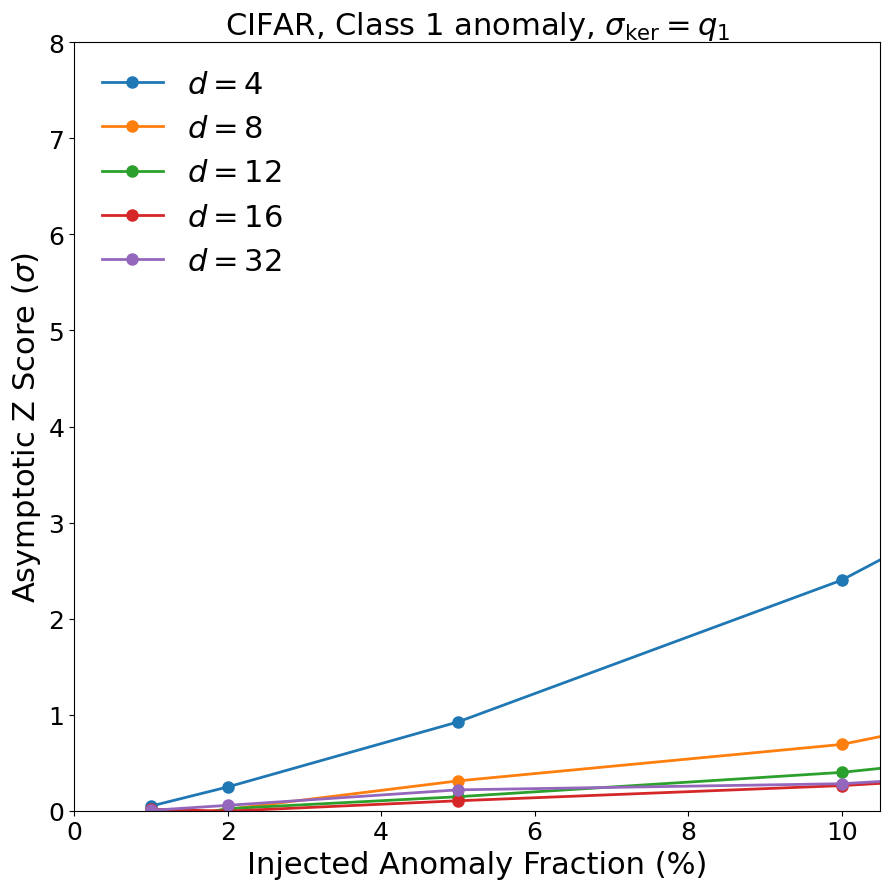

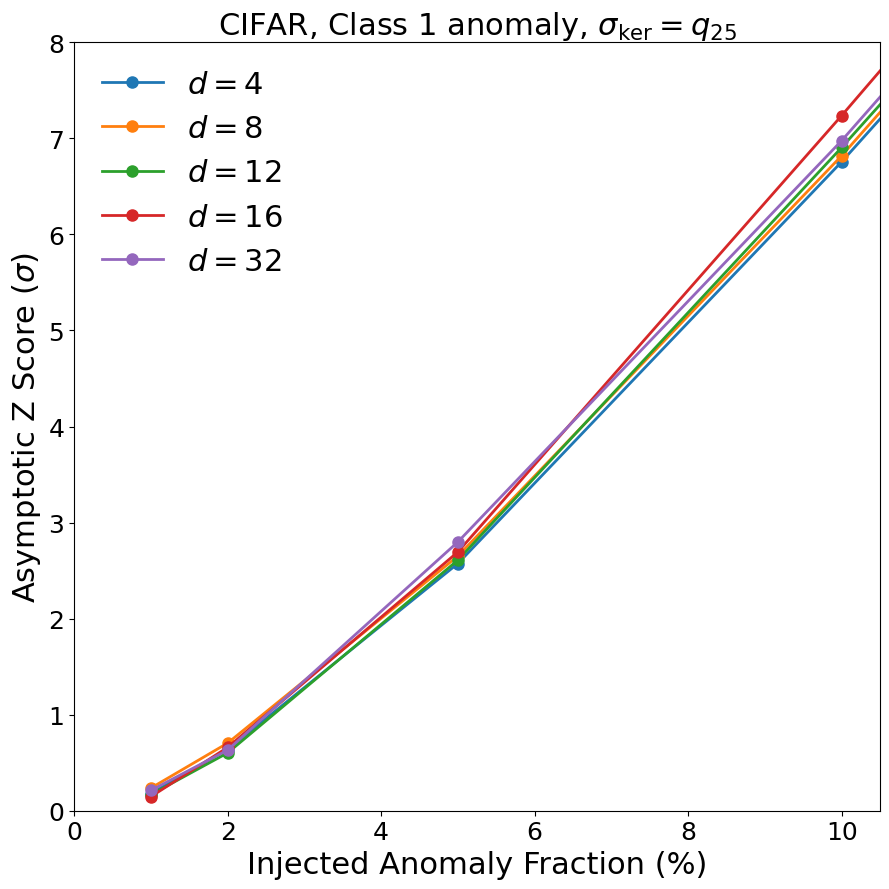

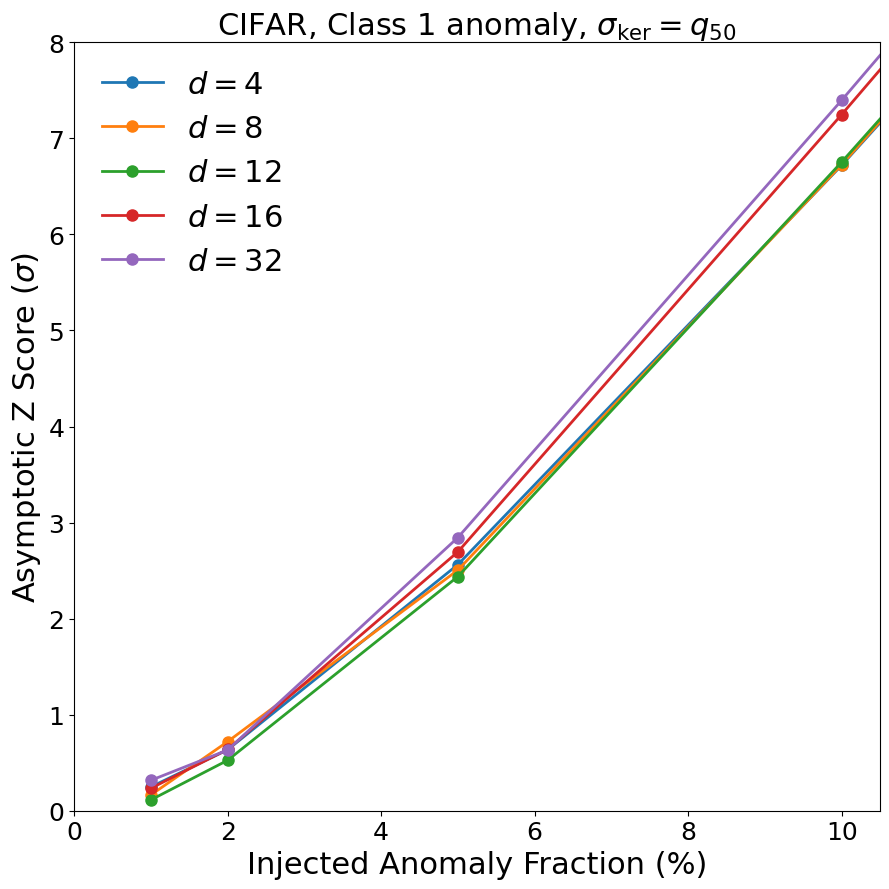

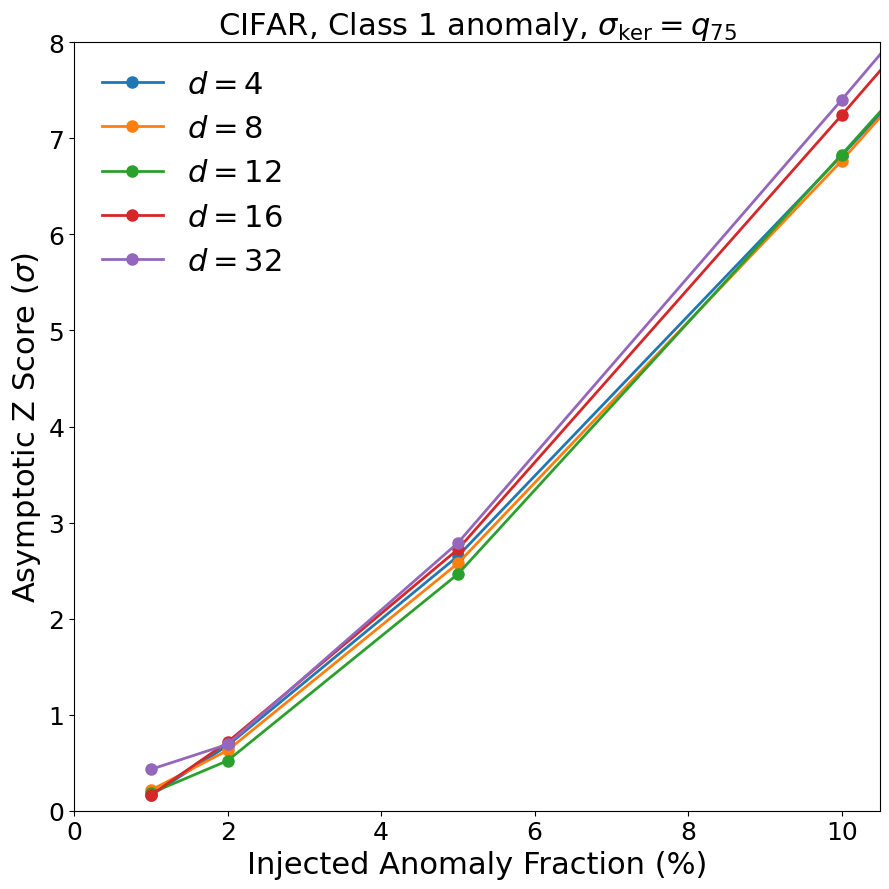

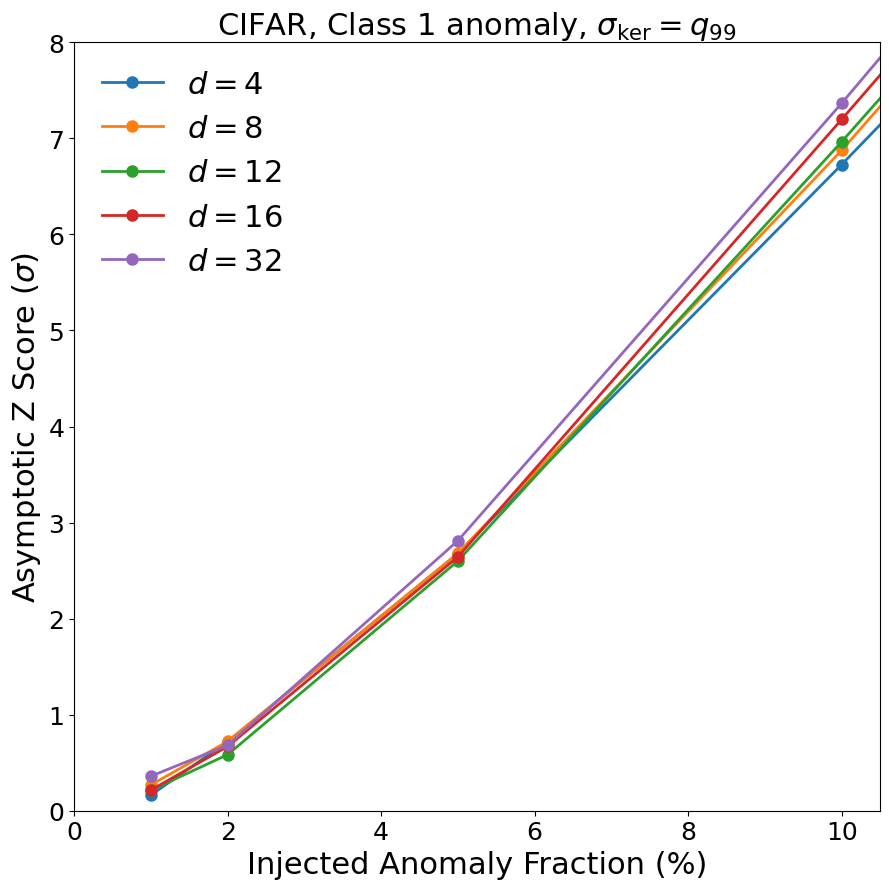

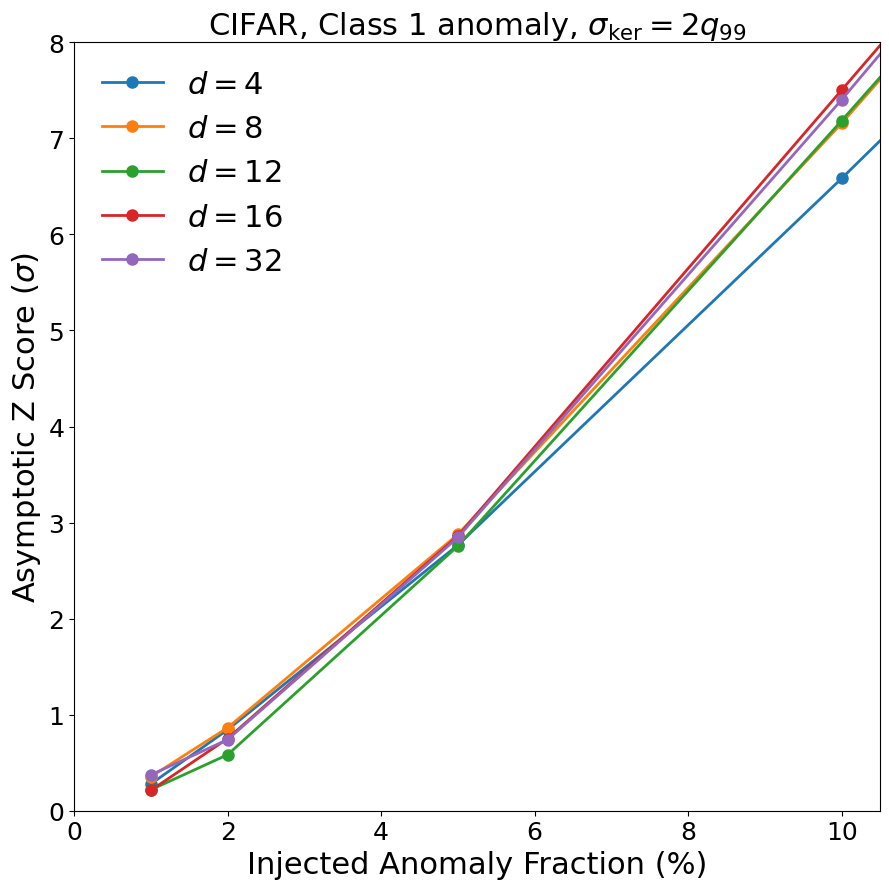

In [5]:
for sigma in flk_sigmas:
    plt.figure(figsize=(9,9))
    for idim,dim in enumerate(dims):
        inj_fractions = analysis_results[dim]['inj_fractions']
        z_obs = analysis_results[dim]['statistics']['z_obs']
    
        x_values = [100*f for f in inj_fractions]
        y_values = [z_obs[f][:,flk_sigmas.index(sigma)] for f in inj_fractions]
        
        plt.plot(x_values,y_values,lw=2,
                marker='o',markersize=8,
                color=f"C{idim}",
                label=f"$d = {dim}$")
    plt.legend(fontsize=22, frameon=False, loc='upper left')
    #plt.title(f"CIFAR, Class 1 anomaly, $\sigma_\\text{{ker}} = {sigma:.1f}$",fontsize=22)
    plt.title(f"CIFAR, Class 1 anomaly, {plotting.kernel_to_label[sigma]}",fontsize=22)
    plt.xlim([0,10.5])
    plt.ylim([0,8])
    plt.yticks(fontsize=18)
    plt.xticks(fontsize=18)
    plt.ylabel("Asymptotic Z Score ($\sigma$)",fontsize=22)
    plt.xlabel("Injected Anomaly Fraction (%)",fontsize=22)
    plt.tight_layout()
    plt.savefig(f"cifar_plots/cifar10asymptoticZscores_varyDim_sigma{sigma:.1f}.pdf",bbox_inches='tight')

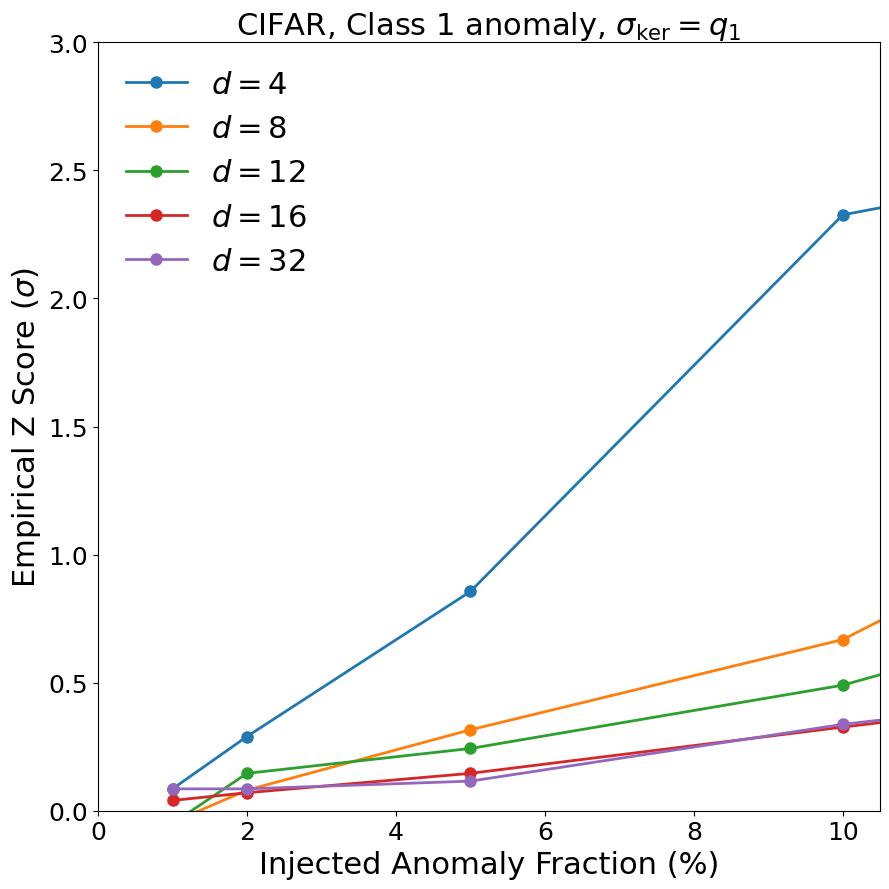

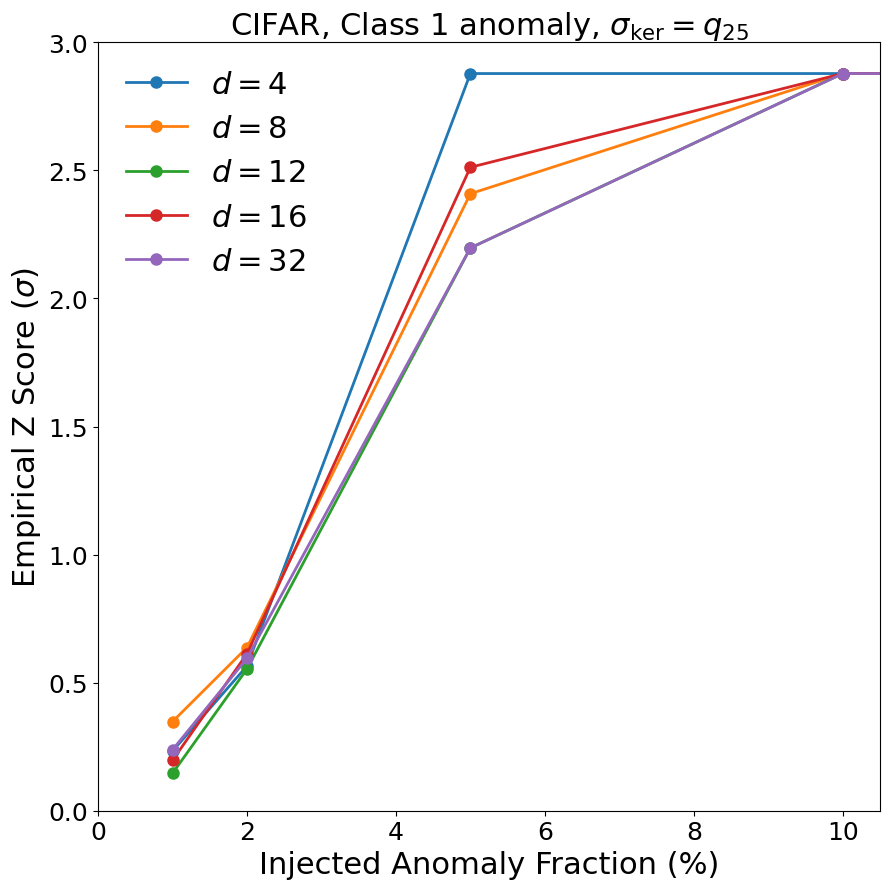

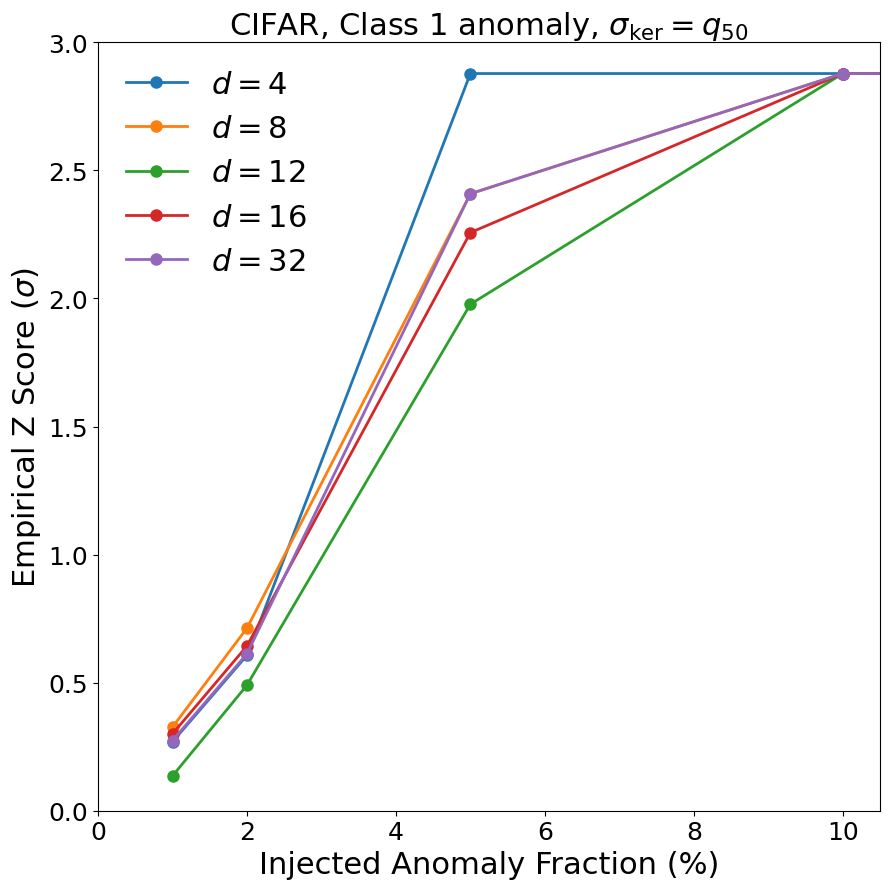

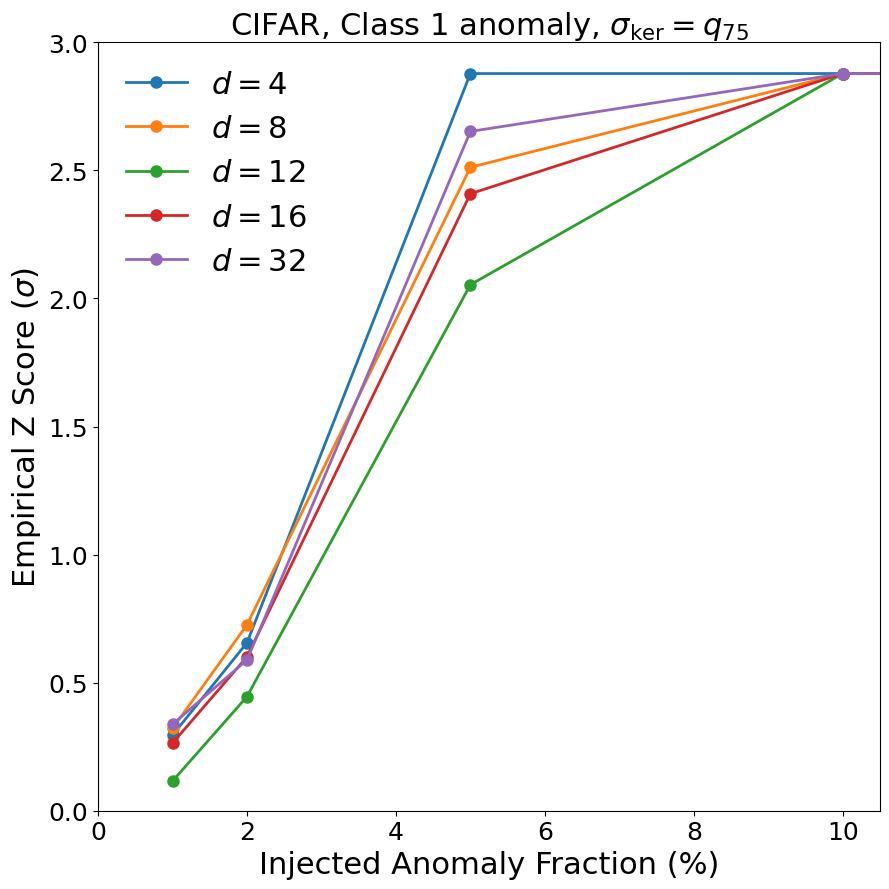

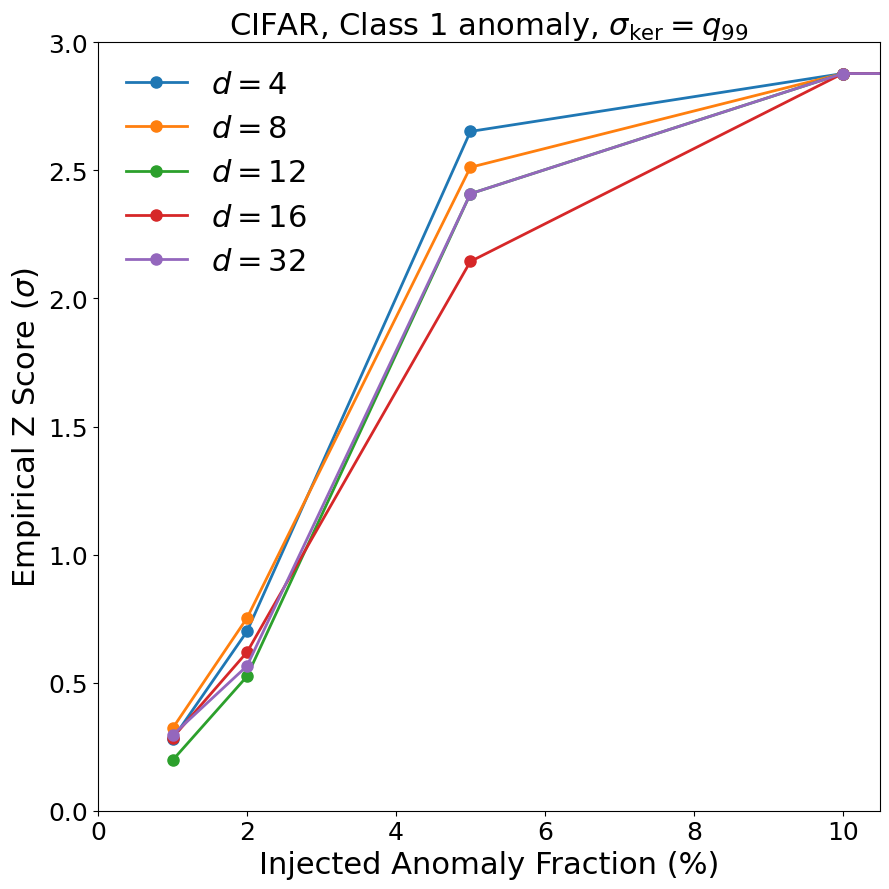

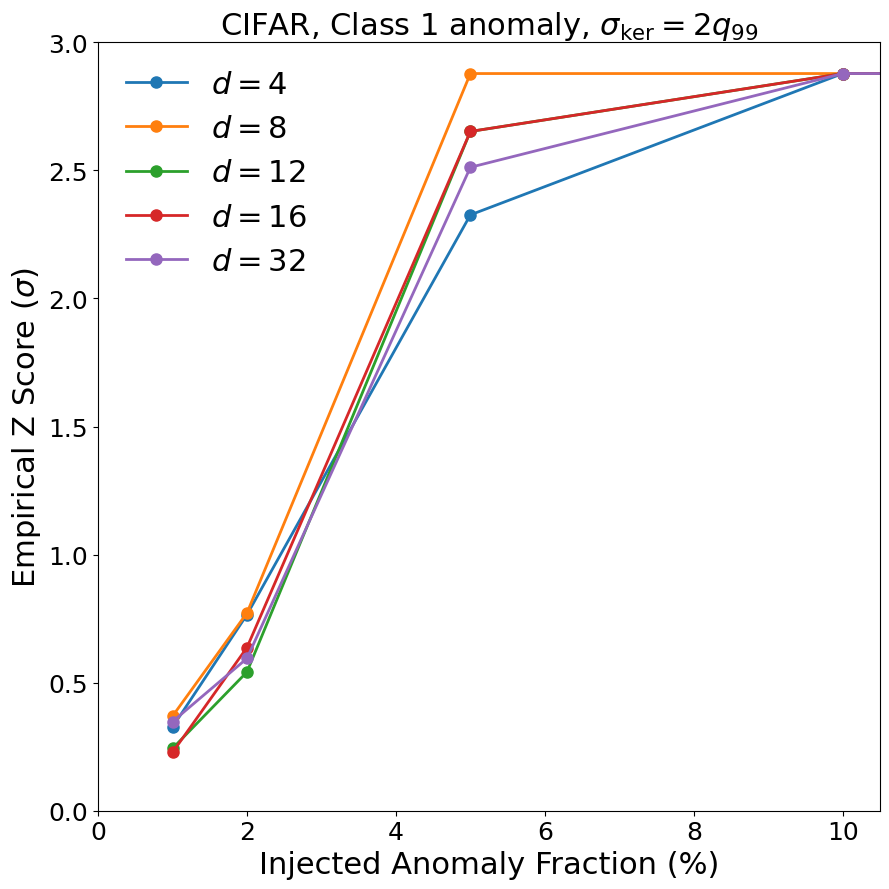

In [6]:
for sigma in flk_sigmas:
    plt.figure(figsize=(9,9))
    for idim,dim in enumerate(dims):
        inj_fractions = analysis_results[dim]['inj_fractions']
        z_obs = analysis_results[dim]['statistics']['z_emp']
    
        x_values = [100*f for f in inj_fractions]
        y_values = [z_obs[f][:,flk_sigmas.index(sigma)] for f in inj_fractions]
        
        plt.plot(x_values,y_values,lw=2,
                marker='o',markersize=8,
                color=f"C{idim}",
                label=f"$d = {dim}$")
    plt.legend(fontsize=22, frameon=False, loc='upper left')
    #plt.title(f"CIFAR, Class 1 anomaly, $\sigma_\\text{{ker}} = {sigma:.1f}$",fontsize=22)
    plt.title(f"CIFAR, Class 1 anomaly, {plotting.kernel_to_label[sigma]}",fontsize=22)
    plt.xlim([0,10.5])
    plt.ylim([0,3])
    plt.yticks(fontsize=18)
    plt.xticks(fontsize=18)
    plt.ylabel("Empirical Z Score ($\sigma$)",fontsize=22)
    plt.xlabel("Injected Anomaly Fraction (%)",fontsize=22)
    plt.tight_layout()
    plt.savefig(f"cifar_plots/cifar10empiricalZscores_varyDim_sigma{sigma:.1f}.pdf",bbox_inches='tight')

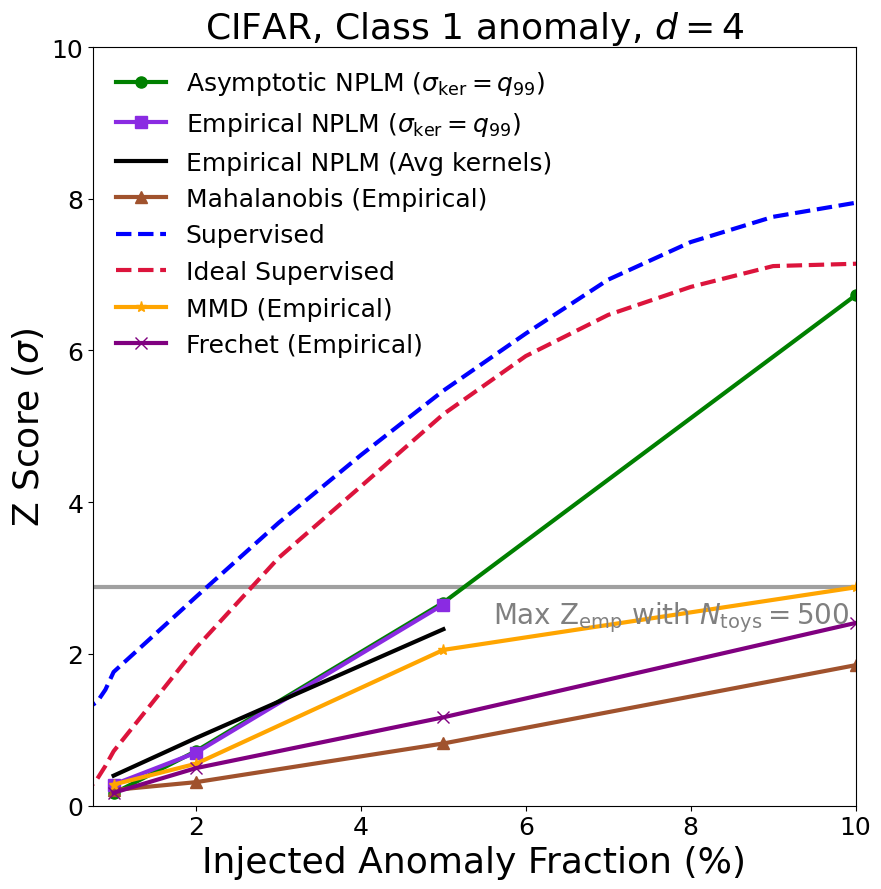

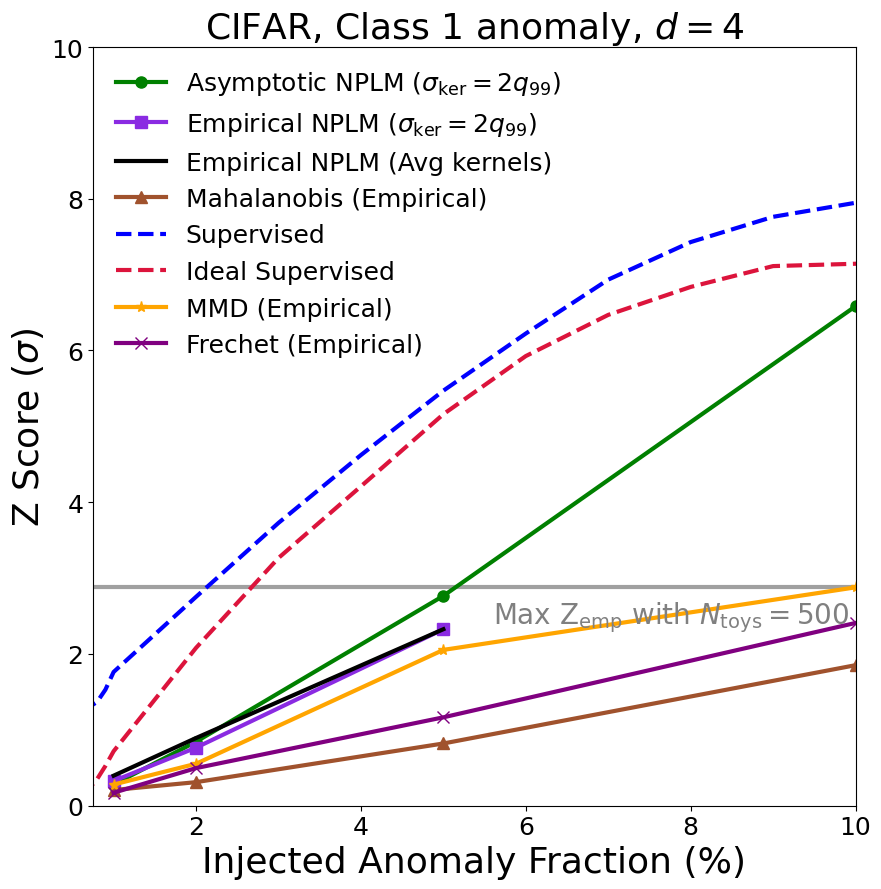

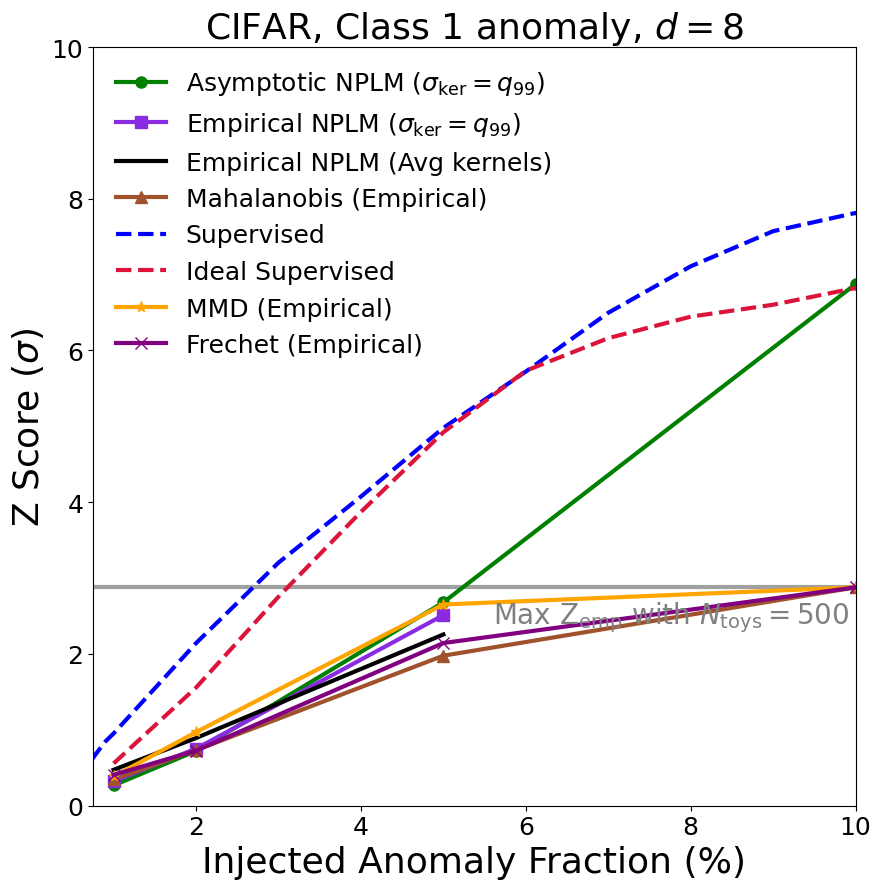

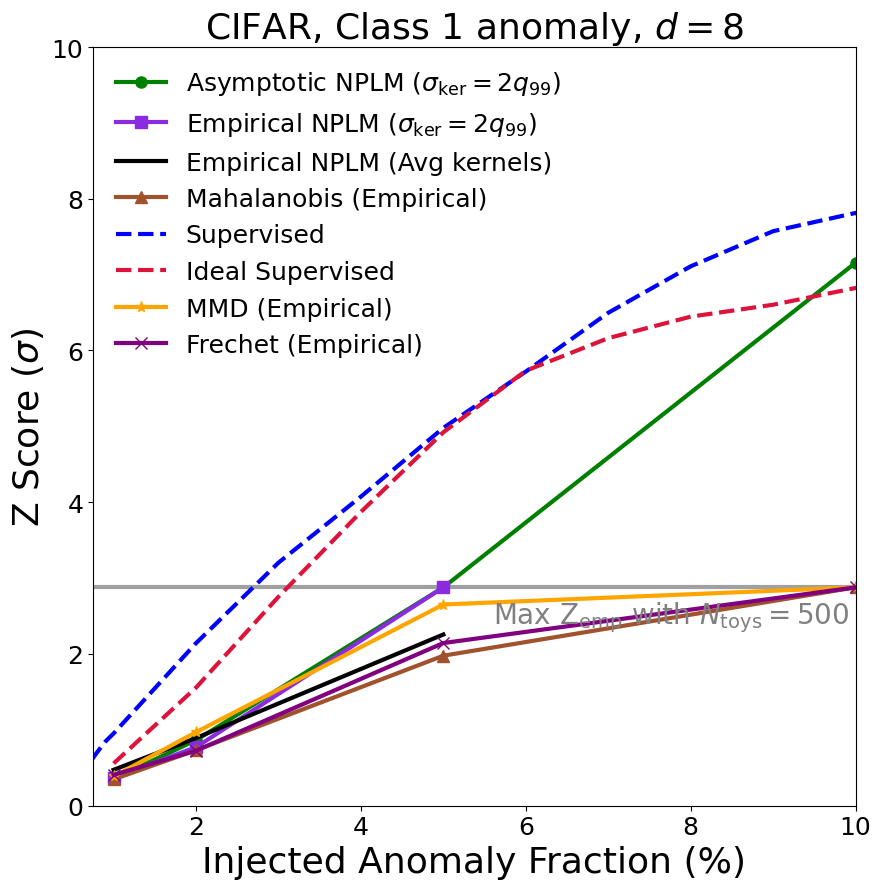

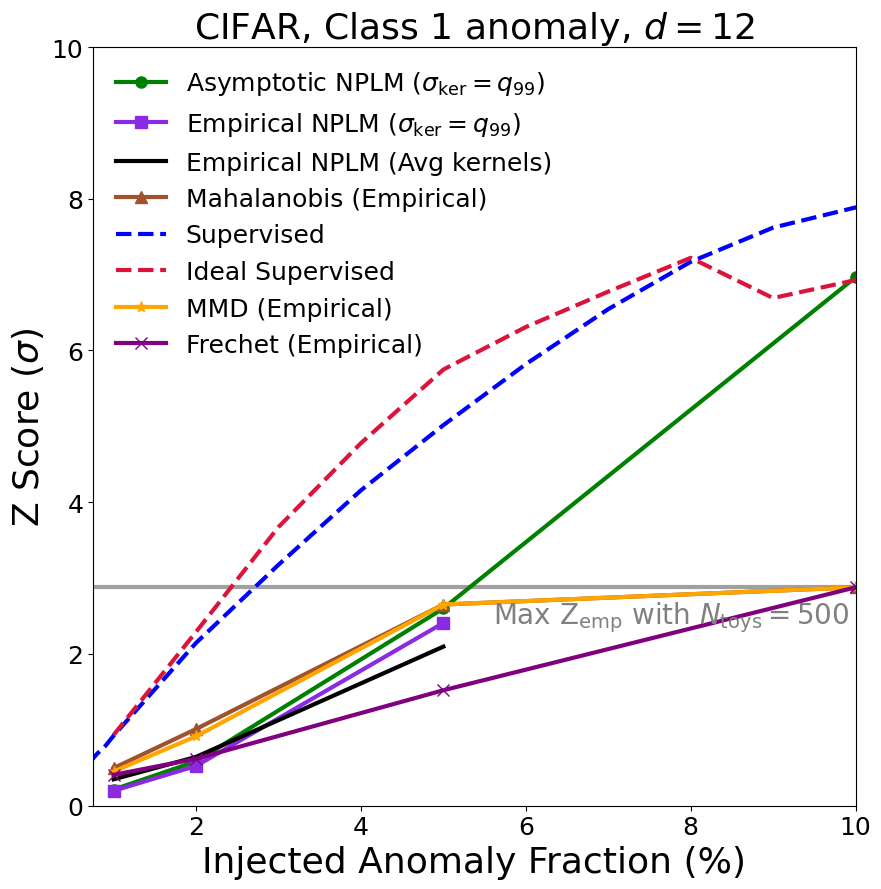

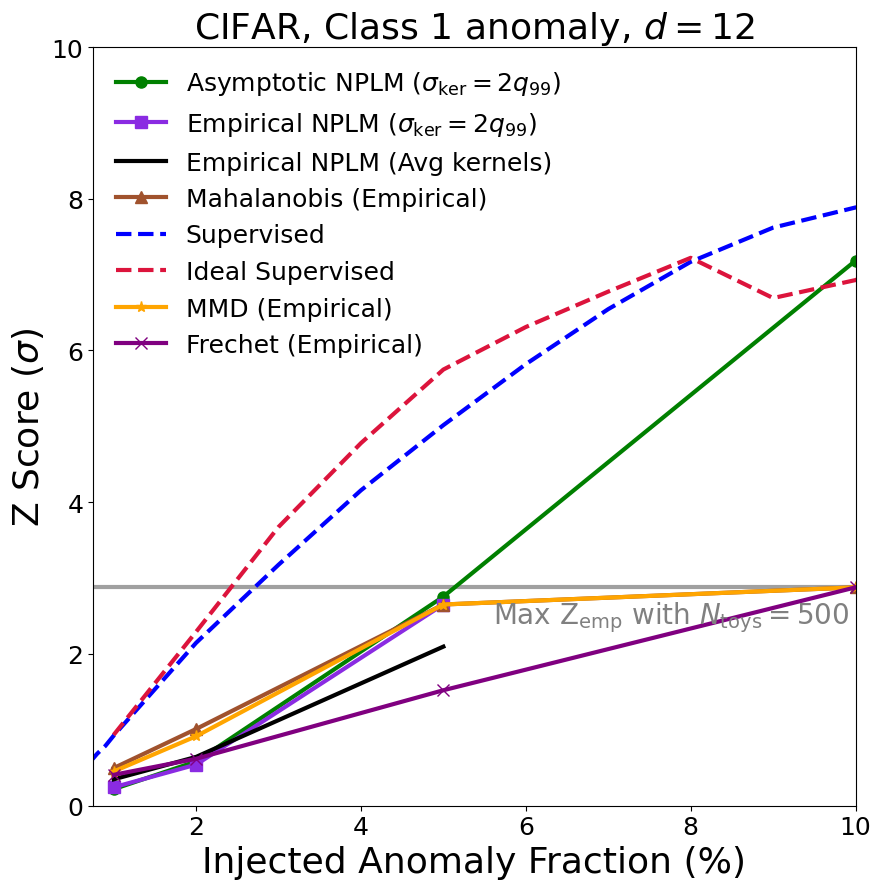

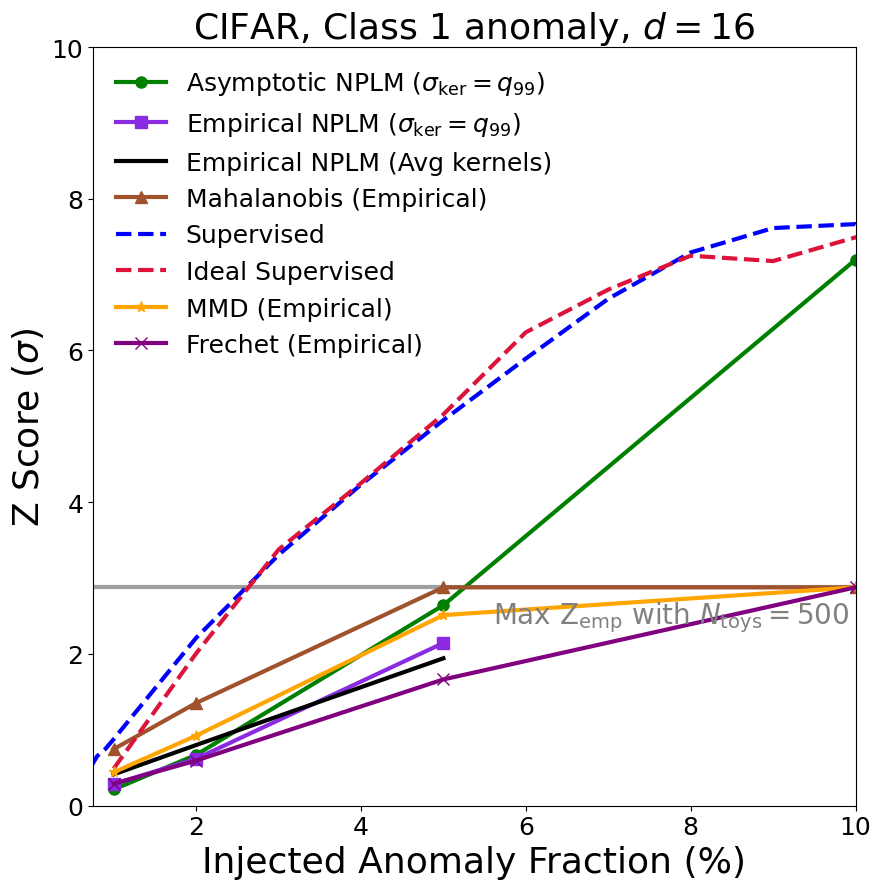

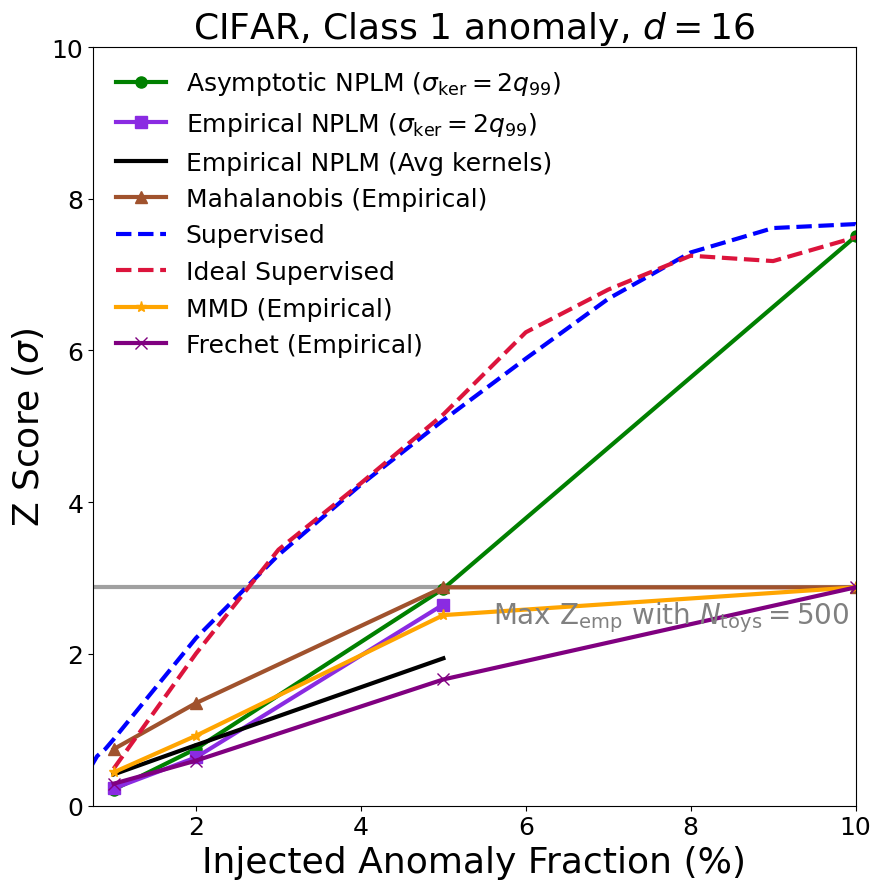

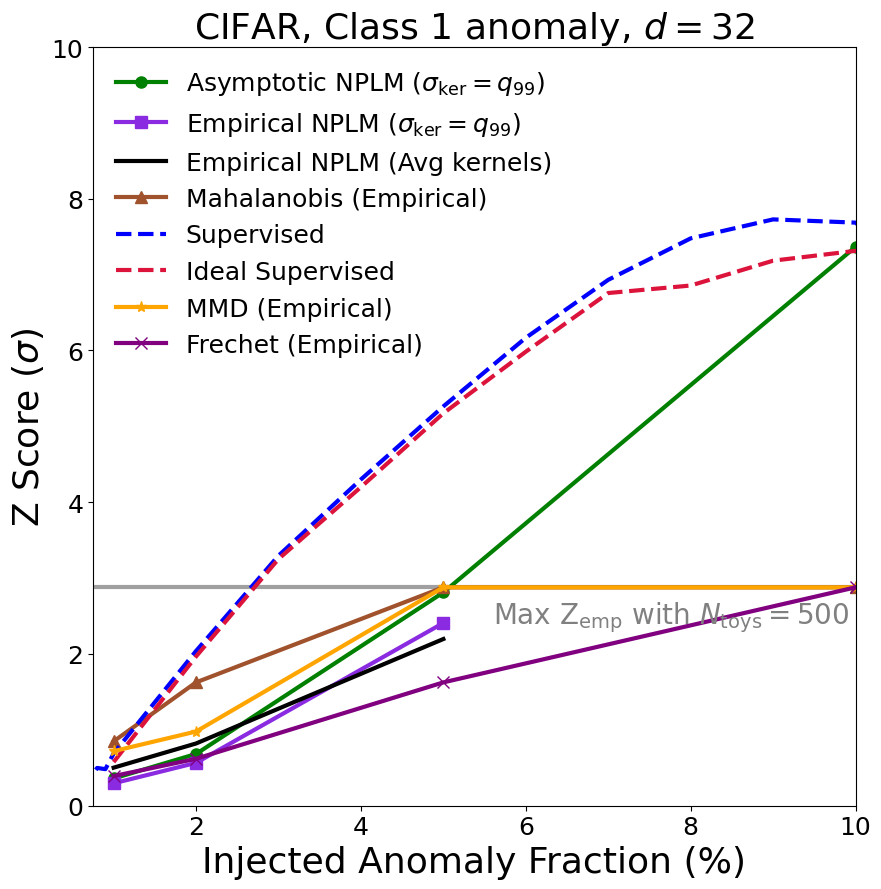

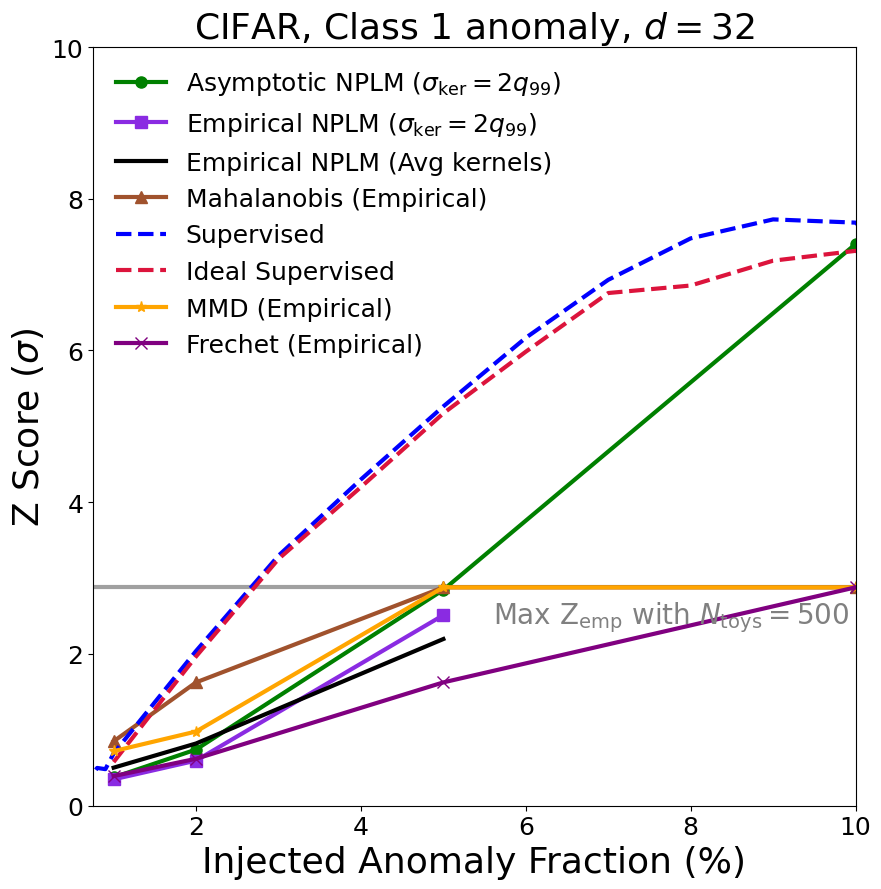

In [7]:
for dim in dims:
    for best_sigma in [4.9,9.8]:
        plt.figure(figsize=(9,9))
        plt.title(f"CIFAR, Class 1 anomaly, $d = {dim}$",fontsize=26)
        inj_fractions = analysis_results[dim]['inj_fractions']
        z_obs = analysis_results[dim]['statistics']['z_obs']
        z_emp = analysis_results[dim]['statistics']['z_emp']
        z_avg = analysis_results[dim]['statistics']['z_avg']
        maha_emp_zscores = analysis_results[dim]['maha_emp_zscores']
        ideal_zscores = analysis_results[dim]['ideal_zscores']
        double_ideal_zscores = analysis_results[dim]['double_ideal_zscores']

        x_values = [100*f for f in inj_fractions]
        isigma = flk_sigmas.index(best_sigma)
        handles_1=[]
        sigma_label = plotting.kernel_to_label[best_sigma]

        # asymptotic
        y_values = [z_obs[f][:,isigma] for f in inj_fractions]
        l1,=plt.plot(x_values,y_values,lw=3,
                marker='o',markersize=8,color='green',
                label=f"Asymptotic NPLM ({sigma_label})")
        handles_1.append(l1)

        #empirical
        y_values = [z_emp[f][:,isigma] for f in inj_fractions]
        l2,=plt.plot(x_values[:-2],y_values[:-2],lw=3,
                marker='s',markersize=8,color='blueviolet',
                label=f"Empirical NPLM ({sigma_label})")
        handles_1.append(l2)

        # avg empirical
        l3,=plt.plot(x_values[:-2],[z_avg[f] for f in inj_fractions][:-2],lw=3, linestyle='-',
                marker=None,color="k",label=f"Empirical NPLM (Avg kernels)")
        handles_1.append(l3)

        # maha
        l7, = plt.plot(100*maha_emp_zscores['fracs'],maha_emp_zscores['zscores'],lw=3,color='sienna',label="Mahalanobis (Empirical)",
                    marker='^',markersize=8)
        handles_1.append(l7)

        # supervised
        xlim = plt.gca().get_xlim()
        l4,=plt.plot(100*ideal_zscores['fracs'],ideal_zscores['zscores'],
                lw=3,linestyle='--',color='blue',label='Supervised')
        handles_1.append(l4)
        # ideal supervised
        l5,=plt.plot(100*double_ideal_zscores['fracs'],double_ideal_zscores['zscores'],
                lw=3,linestyle='--',color='crimson',label='Ideal Supervised')
        handles_1.append(l5)

        l6= plt.axhline(norm.ppf(1-1./NTOYS),lw=3,linestyle='-',color='gray',zorder=0,label=f"Max Z with $N_\\text{{toys}} = 500$",alpha=0.75)
        handles_2 = [l6]

        # mmd
        y_values = [analysis_results[dim]['z_emp_mmd'][f] for f in analysis_results[dim]['inj_fractions_mmd']]
        l8, = plt.plot(100*np.array(inj_fractions_mmd),y_values,lw=3,color='orange',label="MMD (Empirical)",
                marker='*',markersize=8)
        handles_1.append(l8)

        # Frechet
        y_values = [analysis_results[dim]['z_emp_fid'][f] for f in analysis_results[dim]['inj_fractions_fid']]
        l9, = plt.plot(100*np.array(inj_fractions_fid),y_values,lw=3,color='purple',label="Frechet (Empirical)",
                marker='x',markersize=8)
        handles_1.append(l9)

        plt.xlim(xlim)
        plt.xlim([0.75,10])
        plt.ylim([0,10])
        plt.yticks(fontsize=18)
        plt.xticks(fontsize=18)
        plt.ylabel("Z Score ($\sigma$)",fontsize=26)
        plt.xlabel("Injected Anomaly Fraction (%)",fontsize=26)
        #plt.grid(axis='y')
        leg1 = plt.legend(handles=handles_1,ncol=1,fontsize=18,frameon=False,loc='upper left')
        #leg2 = plt.legend(handles=handles_2,ncol=1,fontsize=20,frameon=False,loc='lower right')
        #plt.gca().add_artist(leg1)
        plt.text(5.6,2.4,f"Max Z$_\\text{{emp}}$ with $N_\\text{{toys}} = 500$",fontsize=20,color='gray')
        plt.tight_layout()
        plt.savefig(f"cifar_plots/cifar10_class1Anom_Zsummary_dim{dim}_sigma{best_sigma}.pdf")

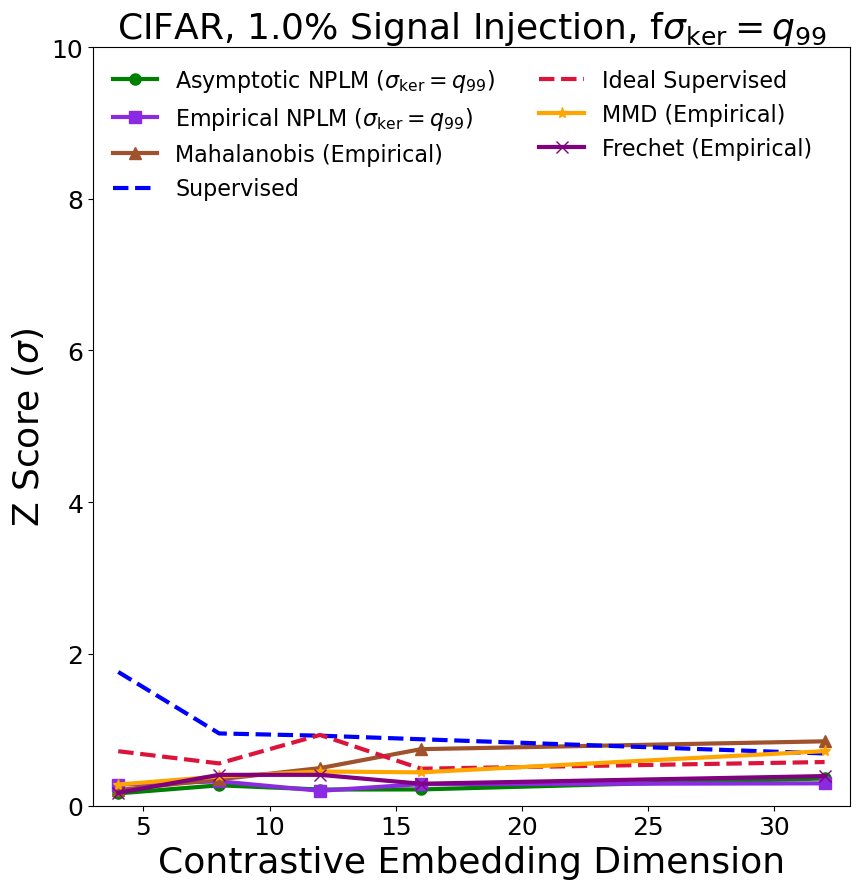

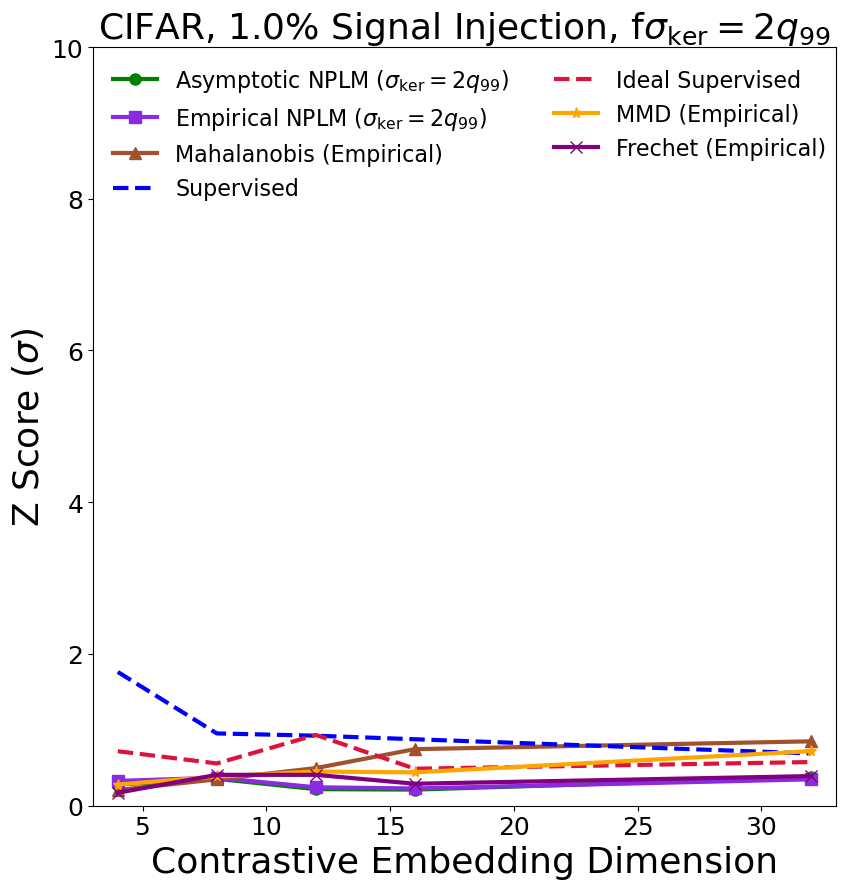

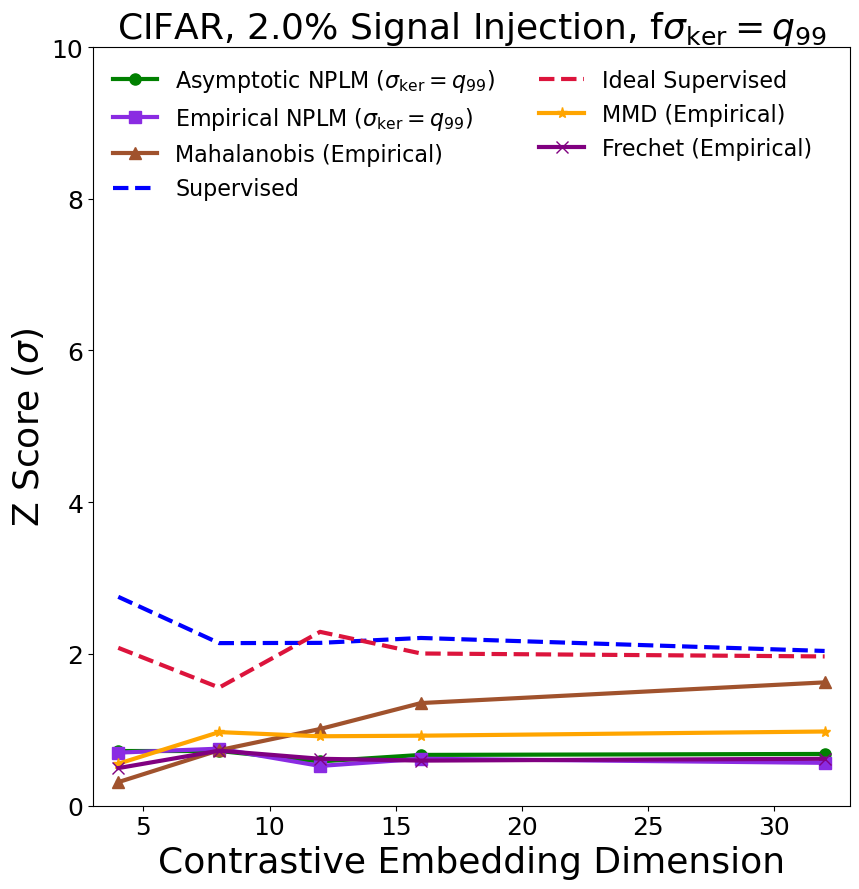

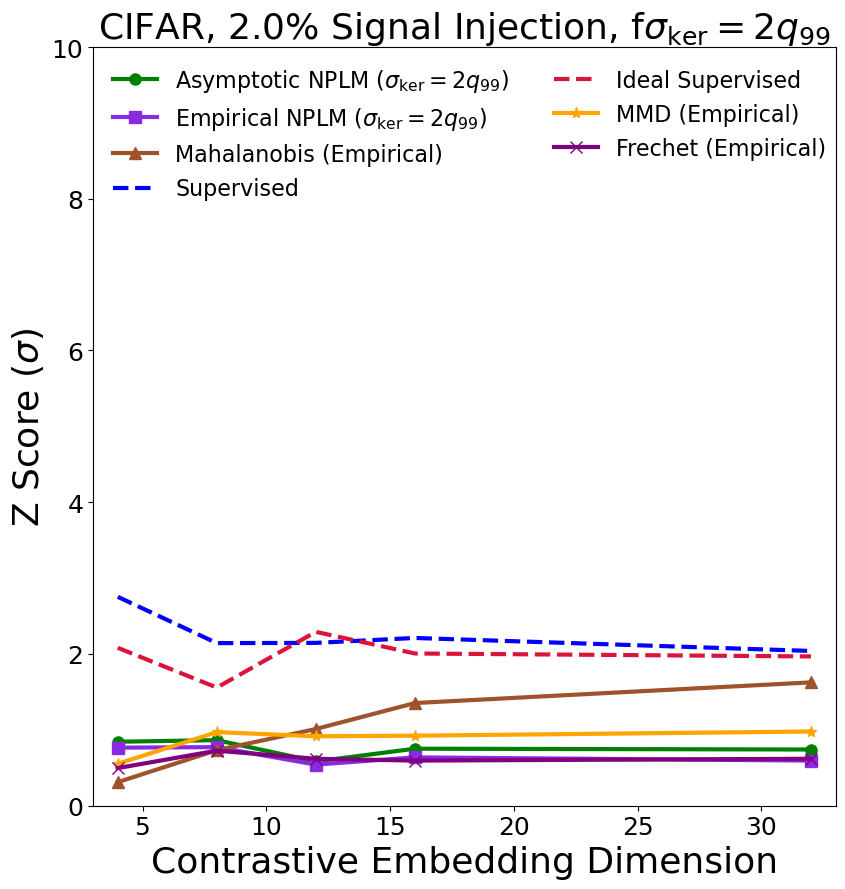

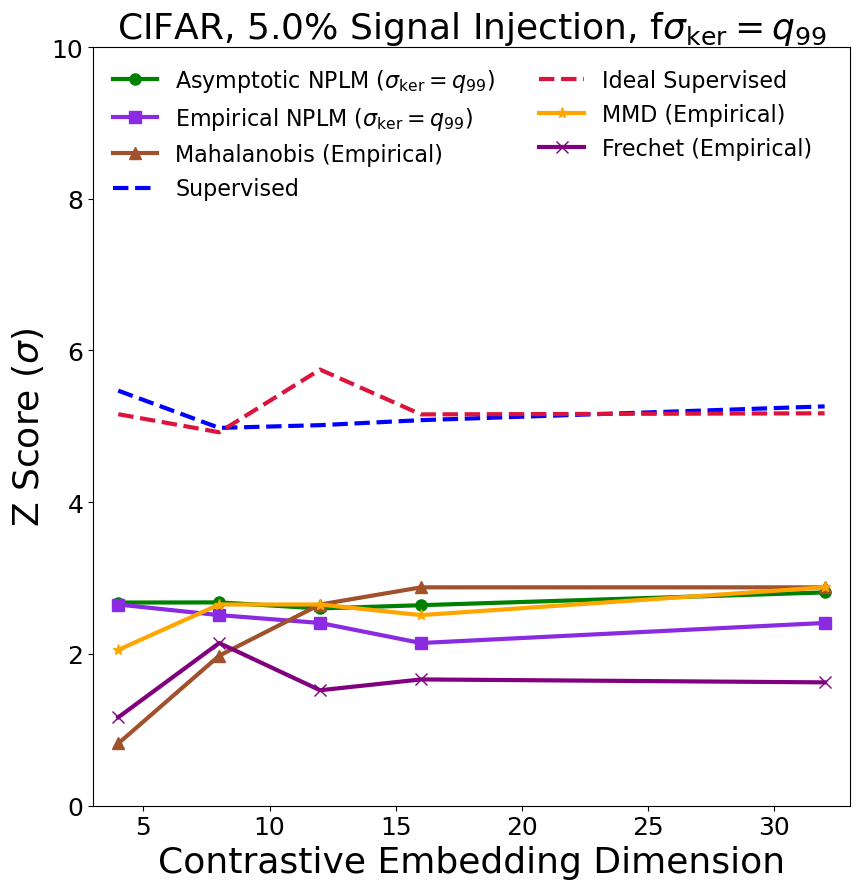

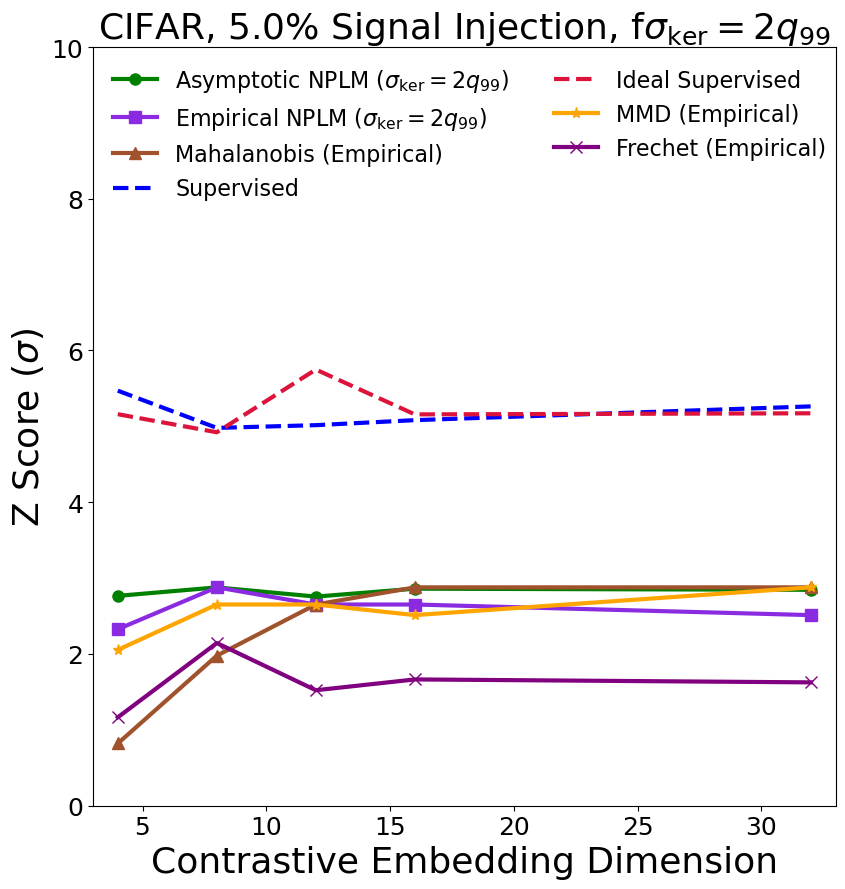

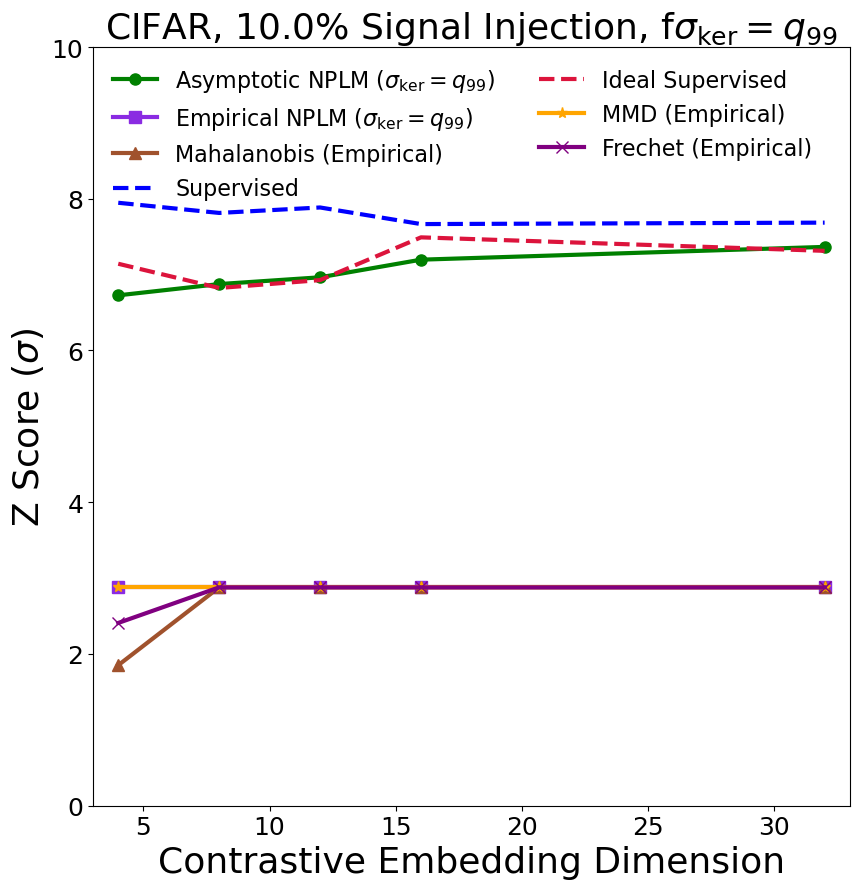

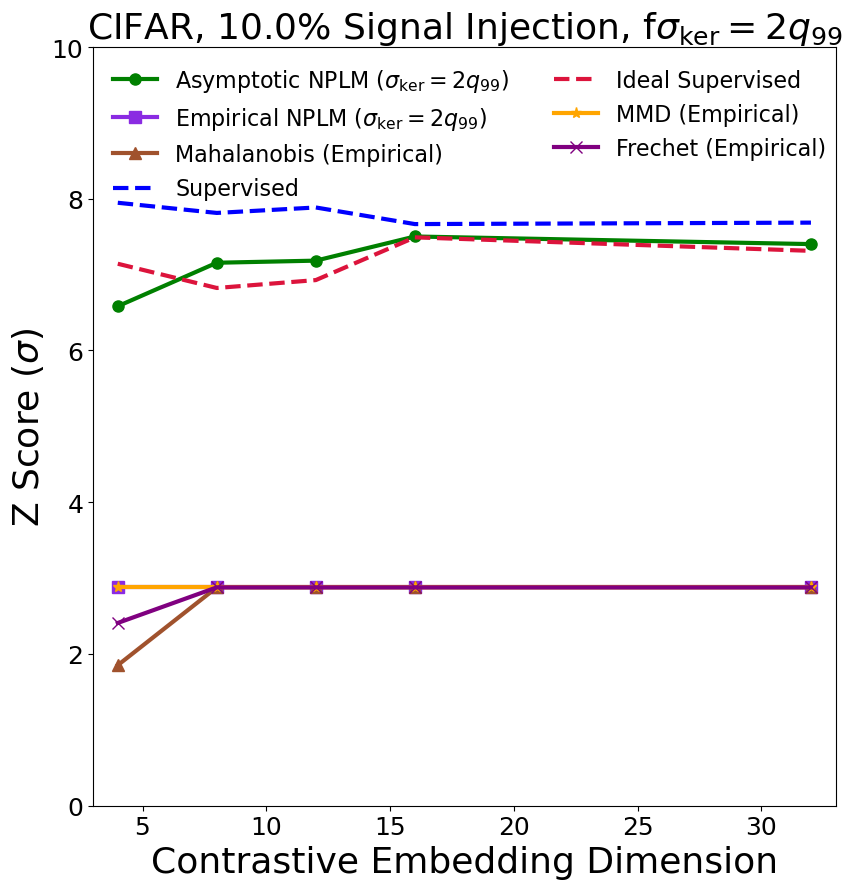

In [3]:
#fraction = 0.1
for fraction in [0.01,0.02,0.05,0.1]:
    for best_sigma in [4.9,9.8]:
        plt.figure(figsize=(9,9))
        plt.title(f"CIFAR, {100*fraction}% Signal Injection, f{plotting.kernel_to_label[best_sigma]}",fontsize=26)
        inj_fractions = analysis_results[dim]['inj_fractions']
        
        ideal_zscores = analysis_results[dim]['ideal_zscores']
        double_ideal_zscores = analysis_results[dim]['double_ideal_zscores']

        x_values = dims
        isigma = flk_sigmas.index(best_sigma)
        handles_1=[]
        sigma_label = plotting.kernel_to_label[best_sigma]

        # asymptotic
        y_values = [analysis_results[d]['statistics']['z_obs'][fraction][:,isigma] for d in dims]
        l1,=plt.plot(x_values,y_values,lw=3,
                marker='o',markersize=8,color='green',
                label=f"Asymptotic NPLM ({sigma_label})")
                #label=f"Asymptotic NPLM ($\sigma_\\text{{ker}} = {best_sigma:.1f}$)")
        handles_1.append(l1)

        #empirical
        y_values = [analysis_results[d]['statistics']['z_emp'][fraction][:,isigma] for d in dims]
        l2,=plt.plot(x_values,y_values,lw=3,
                marker='s',markersize=8,color='blueviolet',
                #label=f"Empirical NPLM ($\sigma_\\text{{ker}} = {best_sigma:.1f}$)")
                label=f"Empirical NPLM ({sigma_label})")
        handles_1.append(l2)

        # avg empirical
        #l3,=plt.plot(x_values,[analysis_results[d]['statistics']['z_avg'][fraction] for d in dims],lw=3, linestyle='-',
        #        marker=None,color="k",label=f"Empirical NPLM (Avg kernels)")
        #handles_1.append(l3)

        # maha
        l7, = plt.plot(x_values,[analysis_results[d]['maha_emp_zscores']['zscores'][list(analysis_results[d]['maha_emp_zscores']['fracs']).index(fraction)] for d in dims],lw=3,color='sienna',label="Mahalanobis (Empirical)",
                        marker='^',markersize=8)
        handles_1.append(l7)

        # supervised
        xlim = plt.gca().get_xlim()
        l4,=plt.plot(x_values, [analysis_results[d]['ideal_zscores']['zscores'][list(analysis_results[d]['ideal_zscores']['fracs']).index(fraction)] for d in dims],
                lw=3,linestyle='--',color='blue',label='Supervised')
        handles_1.append(l4)
        # ideal supervised
        l5,=plt.plot(x_values,[analysis_results[d]['double_ideal_zscores']['zscores'][list(analysis_results[d]['double_ideal_zscores']['fracs']).index(fraction)] for d in dims],
                lw=3,linestyle='--',color='crimson',label='Ideal Supervised')
        handles_1.append(l5)

        #l6= plt.axhline(norm.ppf(1-1./NTOYS),lw=3,linestyle='-',color='gray',zorder=0,label=f"Max Z with $N_\\text{{toys}} = 500$",alpha=0.75)
        #handles_2 = [l6]

        # mmd
        y_values = [analysis_results[d]['z_emp_mmd'][fraction] for d in dims]
        l8, = plt.plot(dims,y_values,lw=3,color='orange',label="MMD (Empirical)",
                marker='*',markersize=8)
        handles_1.append(l8)

        # Frechet
        y_values = [analysis_results[d]['z_emp_fid'][fraction] for d in dims]
        l9, = plt.plot(dims,y_values,lw=3,color='purple',label="Frechet (Empirical)",
                marker='x',markersize=8)
        handles_1.append(l9)

        plt.xlim([3,33])
        plt.ylim([0,10])
        plt.yticks(fontsize=18)
        plt.xticks(fontsize=18)
        plt.ylabel("Z Score ($\sigma$)",fontsize=26)
        plt.xlabel("Contrastive Embedding Dimension",fontsize=26)
        #plt.grid(axis='y')
        #if fraction == 0.01:
        leg1 = plt.legend(handles=handles_1,ncol=2,fontsize=16,frameon=False,loc='upper left')
        #leg2 = plt.legend(handles=handles_2,ncol=1,fontsize=20,frameon=False,loc='lower right')
        #plt.gca().add_artist(leg1)
        #plt.text(5.6,2.4,f"Max Z$_\\text{{emp}}$ with $N_\\text{{toys}} = 500$",fontsize=20,color='gray')
        plt.tight_layout()
        plt.savefig(f"cifar_plots/cifar10_class1Anom_Zsummary_dimScan_sigma{best_sigma}_frac{fraction}.pdf")